In [113]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

from Countries import oecd_countries, imf_advanced_countries, imf_emerging_countries


In [3]:
# URL of the CSV file
url = "https://dataverse.nl/api/access/datafile/354098"

# Read the CSV file into a DataFrame
df = pd.read_stata(url)
df.head(10)

,countrycode,country,currency_unit,year,rgdpe,rgdpo,pop,emp,avh,hc,...,csh_x,csh_m,csh_r,pl_c,pl_i,pl_g,pl_x,pl_m,pl_n,pl_k
0,ABW,Aruba,Aruban Guilder,1950,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,Aruba,Aruban Guilder,1951,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,Aruba,Aruban Guilder,1952,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABW,Aruba,Aruban Guilder,1953,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,Aruba,Aruban Guilder,1954,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ABW,Aruba,Aruban Guilder,1955,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,ABW,Aruba,Aruban Guilder,1956,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,ABW,Aruba,Aruban Guilder,1957,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,ABW,Aruba,Aruban Guilder,1958,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,ABW,Aruba,Aruban Guilder,1959,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# filter the df for the variables of interest
var_of_int = ["countrycode", "country", "year", "rgdpna", "rnna", "emp", "hc", "labsh"]

pwt_csv = df[var_of_int]

# rename some columns
pwt_csv = pwt_csv.rename(columns = {'rgdpna':'y', "rnna":"k"})

# drop nan and reset index
pwt_csv.dropna(inplace=True)
pwt_csv.reset_index(inplace=True, drop=True) 

# Generate missing variables 
pwt_csv["cap_out"] = pwt_csv["k"] / pwt_csv["y"] # capital output ratio
pwt_csv["HC"] = pwt_csv["hc"] * pwt_csv["emp"] # aggregate human capital
pwt_csv["capsh"] = 1 - pwt_csv["labsh"] # capital share as reciproc of labsh

# log transform
pwt_csv["lnY"] = np.log(pwt_csv["y"])
pwt_csv["ln_capsh"] = np.log(pwt_csv["capsh"])
pwt_csv["ln_labsh"] = np.log(pwt_csv["labsh"])
pwt_csv["ln_cap_out"] = np.log(pwt_csv["k"] / pwt_csv["y"])
pwt_csv["ln_cap_out_neg"] = -np.log(pwt_csv["k"] / pwt_csv["y"])




In [5]:
# List of the 4 groups of interest
# entire set
world_data = pwt_csv.copy()
oecd_data = pwt_csv[pwt_csv['countrycode'].isin(oecd_countries)].reset_index(drop=True)
imf_advanced_data = pwt_csv[pwt_csv['countrycode'].isin(imf_advanced_countries)].reset_index(drop=True)
imf_emerging_data = pwt_csv[pwt_csv['countrycode'].isin(imf_emerging_countries)].reset_index(drop=True)

In [6]:
oecd_data.head(10)

,countrycode,country,year,y,k,emp,hc,labsh,cap_out,HC,capsh,lnY,ln_capsh,ln_labsh,ln_cap_out,ln_cap_out_neg
0,AUS,Australia,1950,127476.031250,569058.8125,3.429873,2.667302,0.680492,4.464046,9.148508,0.319508,11.755684,-1.140974,-0.384939,1.496055,-1.496055
1,AUS,Australia,1951,130718.296875,613662.5625,3.523916,2.674344,0.680492,4.694542,9.424162,0.319508,11.780800,-1.140974,-0.384939,1.546401,-1.546401
2,AUS,Australia,1952,125367.687500,626447.8750,3.591675,2.681403,0.680492,4.996885,9.630729,0.319508,11.739006,-1.140974,-0.384939,1.608815,-1.608815
3,AUS,Australia,1953,138968.328125,651768.7500,3.653409,2.688482,0.680492,4.690053,9.822124,0.319508,11.842001,-1.140974,-0.384939,1.545444,-1.545444
4,AUS,Australia,1954,150078.187500,685705.1250,3.731083,2.695580,0.680492,4.568986,10.057433,0.319508,11.918912,-1.140974,-0.384939,1.519291,-1.519291
5,AUS,Australia,1955,155997.843750,720142.5625,3.811291,2.702696,0.680492,4.616362,10.300761,0.319508,11.957598,-1.140974,-0.384939,1.529607,-1.529607
6,AUS,Australia,1956,156355.906250,744715.3125,3.895439,2.711452,0.680492,4.762949,10.562294,0.319508,11.959890,-1.140974,-0.384939,1.560867,-1.560867
7,AUS,Australia,1957,159780.625000,770060.8750,3.946432,2.720236,0.680492,4.819489,10.735226,0.319508,11.981557,-1.140974,-0.384939,1.572668,-1.572668
8,AUS,Australia,1958,170618.890625,803446.8750,3.981427,2.729048,0.680492,4.709015,10.865504,0.319508,12.047188,-1.140974,-0.384939,1.549479,-1.549479
9,AUS,Australia,1959,181070.375000,839937.0000,4.030420,2.737889,0.680492,4.638732,11.034842,0.319508,12.106641,-1.140974,-0.384939,1.534441,-1.534441


In [7]:
oecd_data.describe()

,year,y,k,emp,hc,labsh,cap_out,HC,capsh,lnY,ln_capsh,ln_labsh,ln_cap_out,ln_cap_out_neg
count,2375.000000,2.375000e+03,2.375000e+03,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000
mean,1986.508211,8.493644e+05,3.590305e+06,13.156184,2.749205,0.584174,4.324046,38.892033,0.415826,12.404628,-0.895226,-0.547631,1.402122,-1.402122
std,20.091488,1.987738e+06,7.595504e+06,21.861792,0.589510,0.079307,1.503741,74.265457,0.079308,1.650943,0.188090,0.145606,0.366019,0.366019
min,1950.000000,1.212586e+03,5.848354e+03,0.065468,1.141769,0.316836,0.950069,0.128927,0.229093,7.100511,-1.473628,-1.149370,-0.051221,-2.699624
25%,1969.000000,8.191073e+04,3.377457e+05,2.201043,2.380834,0.545945,3.441322,5.702297,0.359043,11.313384,-1.024314,-0.605237,1.235856,-1.603556
50%,1988.000000,2.495076e+05,1.031462e+06,4.306839,2.803963,0.594380,4.287737,12.276202,0.405620,12.427245,-0.902338,-0.520237,1.455759,-1.455759
75%,2004.000000,7.475042e+05,2.777413e+06,15.827032,3.211613,0.640957,4.970679,40.674477,0.454055,13.524495,-0.789537,-0.444793,1.603556,-1.235856
max,2019.000000,2.056359e+07,6.905946e+07,158.299591,3.891540,0.770907,14.874135,593.519226,0.683164,16.839033,-0.381021,-0.260187,2.699624,0.051221


In [8]:
df2 = pd.read_excel("data/FD Index Database (Excel).xlsx")
df2 = df2[['country','year','FD','FID','FMD']]
df2

,country,year,FD,FID,FMD
0,Aruba,2021,0.289877,0.305223,0.015175
1,Aruba,2020,0.287687,0.305223,0.018175
2,Aruba,2019,0.289003,0.264584,0.014081
3,Aruba,2018,0.293361,0.260210,0.016617
4,Aruba,2017,0.294318,0.251308,0.014244
...,...,...,...,...,...
8059,Western Hemisphere,1984,0.215788,0.182154,0.047051
8060,Western Hemisphere,1983,0.218985,0.188467,0.047903
8061,Western Hemisphere,1982,0.217189,0.189170,0.044101
8062,Western Hemisphere,1981,0.211840,0.176818,0.046166


In [83]:
merged_df = pd.merge(df2, world_data, how='left', on=['country', 'year'])

In [84]:
merged_df

,country,year,FD,FID,FMD,countrycode,y,k,emp,hc,labsh,cap_out,HC,capsh,lnY,ln_capsh,ln_labsh,ln_cap_out,ln_cap_out_neg,country_category
0,Aruba,2021,0.289877,0.305223,0.015175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aruba,2020,0.287687,0.305223,0.018175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Aruba,2019,0.289003,0.264584,0.014081,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Aruba,2018,0.293361,0.260210,0.016617,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Aruba,2017,0.294318,0.251308,0.014244,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8059,Western Hemisphere,1984,0.215788,0.182154,0.047051,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8060,Western Hemisphere,1983,0.218985,0.188467,0.047903,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8061,Western Hemisphere,1982,0.217189,0.189170,0.044101,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8062,Western Hemisphere,1981,0.211840,0.176818,0.046166,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Merged dataframe has the same number of rows as the left dataframe in the merge, meaning the 'left-join' worked as expected.

In [85]:
# Function to categorize countries
def categorize_country(countrycode):
    countrycode = countrycode
    if countrycode in oecd_countries:
        return 'OECD'
    elif countrycode in imf_advanced_countries:
        return 'IMF Advanced'
    elif countrycode in imf_emerging_countries:
        return 'IMF Emerging'
    else:
        return 'Other'

# Create a new column in the DataFrame with the category
merged_df['country_category'] = merged_df['countrycode'].apply(categorize_country)
merged_df

,country,year,FD,FID,FMD,countrycode,y,k,emp,hc,labsh,cap_out,HC,capsh,lnY,ln_capsh,ln_labsh,ln_cap_out,ln_cap_out_neg,country_category
0,Aruba,2021,0.289877,0.305223,0.015175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other
1,Aruba,2020,0.287687,0.305223,0.018175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other
2,Aruba,2019,0.289003,0.264584,0.014081,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other
3,Aruba,2018,0.293361,0.260210,0.016617,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other
4,Aruba,2017,0.294318,0.251308,0.014244,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8059,Western Hemisphere,1984,0.215788,0.182154,0.047051,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other
8060,Western Hemisphere,1983,0.218985,0.188467,0.047903,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other
8061,Western Hemisphere,1982,0.217189,0.189170,0.044101,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other
8062,Western Hemisphere,1981,0.211840,0.176818,0.046166,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other


In [86]:
merged_df.describe()

,year,FD,FID,FMD,y,k,emp,hc,labsh,cap_out,HC,capsh,lnY,ln_capsh,ln_labsh,ln_cap_out,ln_cap_out_neg
count,8064.00000,8064.000000,8064.000000,8064.000000,3.960000e+03,3.960000e+03,3960.000000,3960.000000,3960.000000,3960.000000,3960.000000,3960.000000,3960.000000,3960.000000,3960.000000,3960.000000,3960.000000
mean,2000.50000,0.255437,0.203462,0.148917,6.529566e+05,2.669649e+06,21.661945,2.435550,0.529683,4.253753,51.622406,0.470317,11.584083,-0.789124,-0.666476,1.310730,-1.310730
std,12.12167,0.210133,0.231000,0.224420,1.890573e+06,7.191974e+06,82.542206,0.704992,0.121108,3.089424,186.857574,0.121108,1.962687,0.270305,0.262981,0.502210,0.502210
min,1980.00000,0.000000,0.000000,0.000000,1.430245e+03,2.310930e+03,0.092100,1.014211,0.150073,0.484754,0.171390,0.097011,7.265601,-2.332928,-1.896632,-0.724113,-4.035624
25%,1990.00000,0.102719,0.041697,0.004211,2.272364e+04,8.055785e+04,1.265238,1.880025,0.458165,2.771305,2.781362,0.387959,10.031160,-0.946855,-0.780526,1.019318,-1.594858
50%,2000.50000,0.191612,0.111681,0.042542,1.013980e+05,3.868316e+05,3.619368,2.513557,0.540501,3.829714,8.032825,0.459499,11.526809,-0.777618,-0.615259,1.342790,-1.342790
75%,2011.00000,0.351054,0.274531,0.201929,4.249293e+05,1.800008e+06,10.738504,3.013958,0.612041,4.927629,27.089857,0.541835,12.959678,-0.612794,-0.490956,1.594858,-1.019318
max,2021.00000,1.000000,1.000000,1.000000,2.057261e+07,9.960866e+07,799.306641,4.351568,0.902989,56.578201,2155.971680,0.849927,16.839472,-0.162605,-0.102045,4.035624,0.724113


In [87]:
merged_df = merged_df.dropna()
merged_df

,country,year,FD,FID,FMD,countrycode,y,k,emp,hc,labsh,cap_out,HC,capsh,lnY,ln_capsh,ln_labsh,ln_cap_out,ln_cap_out_neg,country_category
44,Angola,2019,0.096969,0.045453,0.100247,AGO,222151.062500,1.300951e+06,16.644962,1.481984,0.331142,5.856155,24.667574,0.668858,12.311113,-0.402184,-1.105207,1.767493,-1.767493,IMF Emerging
45,Angola,2018,0.144027,0.043575,0.066922,AGO,225540.046875,1.292108e+06,16.078331,1.474635,0.331142,5.728951,23.709661,0.668858,12.326253,-0.402184,-1.105207,1.745532,-1.745532,IMF Emerging
46,Angola,2017,0.148656,0.049994,0.067229,AGO,230151.343750,1.281953e+06,15.544552,1.467321,0.346371,5.570045,22.808849,0.653629,12.346493,-0.425215,-1.060246,1.717403,-1.717403,IMF Emerging
47,Angola,2016,0.154190,0.056435,0.094943,AGO,230491.171875,1.267231e+06,15.028339,1.460044,0.343025,5.497960,21.942038,0.656975,12.347968,-0.420109,-1.069952,1.704377,-1.704377,IMF Emerging
48,Angola,2015,0.147570,0.070821,0.075656,AGO,236594.859375,1.233630e+06,14.529098,1.452803,0.349128,5.214103,21.107916,0.650872,12.374104,-0.429442,-1.052318,1.651367,-1.651367,IMF Emerging
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7681,Zambia,1984,0.149192,0.040375,0.040194,ZMB,14902.924805,1.874219e+05,1.943763,1.687450,0.445721,12.576181,3.280004,0.554279,9.609313,-0.590087,-0.808062,2.531805,-2.531805,IMF Emerging
7682,Zambia,1983,0.156670,0.045299,0.045096,ZMB,14990.561523,1.915574e+05,1.893051,1.656680,0.445721,12.778531,3.136179,0.554279,9.615176,-0.590087,-0.808062,2.547766,-2.547766,IMF Emerging
7683,Zambia,1982,0.193317,0.064173,0.063886,ZMB,14561.939453,1.953781e+05,1.861201,1.626470,0.445721,13.417039,3.027187,0.554279,9.586166,-0.590087,-0.808062,2.596525,-2.596525,IMF Emerging
7684,Zambia,1981,0.196940,0.067229,0.066928,ZMB,14209.801758,1.983052e+05,1.814478,1.596811,0.445721,13.955520,2.897379,0.554279,9.561687,-0.590087,-0.808062,2.635875,-2.635875,IMF Emerging


In [88]:
merged_df.groupby('country').describe()

year                                                       \
               count    mean        std     min      25%     50%      75%   
country                                                                     
Angola          40.0  1999.5  11.690452  1980.0  1989.75  1999.5  2009.25   
Argentina       40.0  1999.5  11.690452  1980.0  1989.75  1999.5  2009.25   
Armenia         30.0  2004.5   8.803408  1990.0  1997.25  2004.5  2011.75   
Australia       40.0  1999.5  11.690452  1980.0  1989.75  1999.5  2009.25   
Austria         40.0  1999.5  11.690452  1980.0  1989.75  1999.5  2009.25   
...              ...     ...        ...     ...      ...     ...      ...   
Ukraine         30.0  2004.5   8.803408  1990.0  1997.25  2004.5  2011.75   
United Kingdom  40.0  1999.5  11.690452  1980.0  1989.75  1999.5  2009.25   
United States   40.0  1999.5  11.690452  1980.0  1989.75  1999.5  2009.25   
Uruguay         40.0  1999.5  11.690452  1980.0  1989.75  1999.5  2009.25   
Zambia          40.0  1999.5  11.690452  1980.0  1989.75  1999.5  2009.25   

                          FD            ... ln_cap_out            \
                   max count      mean  ...        75%       max   
country                                 ...                        
Angola          2019.0  40.0  0.084127  ...   2.087937  2.379178   
Argentina       2019.0  40.0  0.289731  ...   1.169631  1.283443   
Armenia         2019.0  30.0  0.138557  ...   1.198708  1.532081   
Australia       2019.0  40.0  0.733441  ...   1.555212  1.613979   
Austria         2019.0  40.0  0.503374  ...   1.694027  1.725362   
...                ...   ...       ...  ...        ...       ...   
Ukraine         2019.0  30.0  0.158160  ...   2.821883  3.035689   
United Kingdom  2019.0  40.0  0.738052  ...   1.549808  1.567299   
United States   2019.0  40.0  0.789999  ...   1.334323  1.421363   
Uruguay         2019.0  40.0  0.183371  ...   1.578651  1.688474   
Zambia          2019.0  40.0  0.166229  ...   2.310606  2.639149   

               ln_cap_out_neg                                          \
                        count      mean       std       min       25%   
country                                                                 
Angola                   40.0 -1.949077  0.232251 -2.379178 -2.087937   
Argentina                40.0 -1.115150  0.080389 -1.283443 -1.169631   
Armenia                  30.0 -1.006839  0.250642 -1.532081 -1.198708   
Australia                40.0 -1.512996  0.048770 -1.613979 -1.555212   
Austria                  40.0 -1.657554  0.045482 -1.725362 -1.694027   
...                       ...       ...       ...       ...       ...   
Ukraine                  30.0 -2.606241  0.242172 -3.035689 -2.821883   
United Kingdom           40.0 -1.524073  0.027782 -1.567299 -1.549808   
United States            40.0 -1.297908  0.052009 -1.421363 -1.334323   
Uruguay                  40.0 -1.523094  0.078145 -1.688474 -1.578651   
Zambia                   40.0 -1.997453  0.398690 -2.639149 -2.310606   

                                              
                     50%       75%       max  
country                                       
Angola         -1.952775 -1.714147 -1.625872  
Argentina      -1.114368 -1.058939 -0.982323  
Armenia        -0.917426 -0.828708 -0.684740  
Australia      -1.490094 -1.475818 -1.453047  
Austria        -1.662061 -1.622899 -1.538558  
...                  ...       ...       ...  
Ukraine        -2.518835 -2.440422 -2.215496  
United Kingdom -1.527027 -1.503266 -1.461630  
United States  -1.285714 -1.257713 -1.211446  
Uruguay        -1.495841 -1.459237 -1.422166  
Zambia         -2.012196 -1.603689 -1.437693  

[102 rows x 136 columns]

In [89]:
# Group by 'country' and count the number of observations
country_counts = merged_df['country'].value_counts()

# Filter out countries with less than 40 observations
countries_with_40_or_more_observations = country_counts[country_counts >= 40].index

# Filter the original DataFrame based on the selected countries
filtered_df = merged_df[merged_df['country'].isin(countries_with_40_or_more_observations)]

In [90]:
filtered_df

,country,year,FD,FID,FMD,countrycode,y,k,emp,hc,labsh,cap_out,HC,capsh,lnY,ln_capsh,ln_labsh,ln_cap_out,ln_cap_out_neg,country_category
44,Angola,2019,0.096969,0.045453,0.100247,AGO,222151.062500,1.300951e+06,16.644962,1.481984,0.331142,5.856155,24.667574,0.668858,12.311113,-0.402184,-1.105207,1.767493,-1.767493,IMF Emerging
45,Angola,2018,0.144027,0.043575,0.066922,AGO,225540.046875,1.292108e+06,16.078331,1.474635,0.331142,5.728951,23.709661,0.668858,12.326253,-0.402184,-1.105207,1.745532,-1.745532,IMF Emerging
46,Angola,2017,0.148656,0.049994,0.067229,AGO,230151.343750,1.281953e+06,15.544552,1.467321,0.346371,5.570045,22.808849,0.653629,12.346493,-0.425215,-1.060246,1.717403,-1.717403,IMF Emerging
47,Angola,2016,0.154190,0.056435,0.094943,AGO,230491.171875,1.267231e+06,15.028339,1.460044,0.343025,5.497960,21.942038,0.656975,12.347968,-0.420109,-1.069952,1.704377,-1.704377,IMF Emerging
48,Angola,2015,0.147570,0.070821,0.075656,AGO,236594.859375,1.233630e+06,14.529098,1.452803,0.349128,5.214103,21.107916,0.650872,12.374104,-0.429442,-1.052318,1.651367,-1.651367,IMF Emerging
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7681,Zambia,1984,0.149192,0.040375,0.040194,ZMB,14902.924805,1.874219e+05,1.943763,1.687450,0.445721,12.576181,3.280004,0.554279,9.609313,-0.590087,-0.808062,2.531805,-2.531805,IMF Emerging
7682,Zambia,1983,0.156670,0.045299,0.045096,ZMB,14990.561523,1.915574e+05,1.893051,1.656680,0.445721,12.778531,3.136179,0.554279,9.615176,-0.590087,-0.808062,2.547766,-2.547766,IMF Emerging
7683,Zambia,1982,0.193317,0.064173,0.063886,ZMB,14561.939453,1.953781e+05,1.861201,1.626470,0.445721,13.417039,3.027187,0.554279,9.586166,-0.590087,-0.808062,2.596525,-2.596525,IMF Emerging
7684,Zambia,1981,0.196940,0.067229,0.066928,ZMB,14209.801758,1.983052e+05,1.814478,1.596811,0.445721,13.955520,2.897379,0.554279,9.561687,-0.590087,-0.808062,2.635875,-2.635875,IMF Emerging


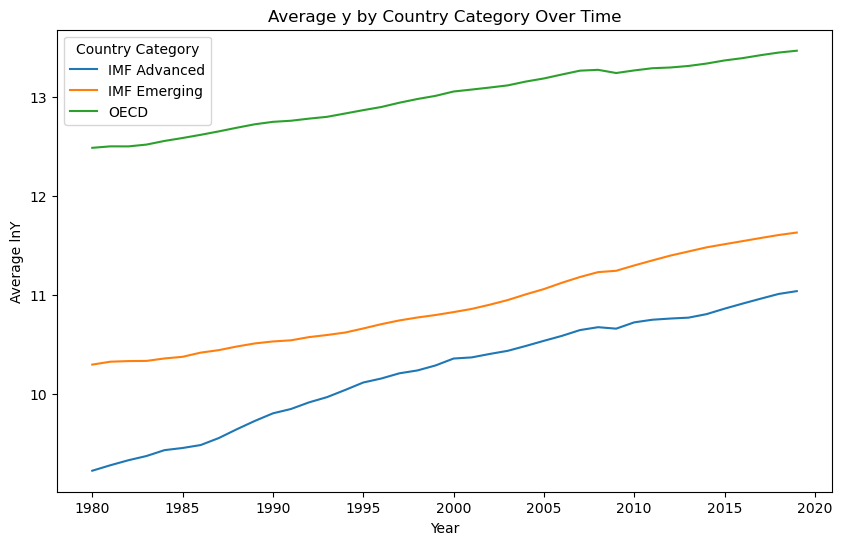

In [134]:
# Calculate the mean ratio for each year
avg_y = filtered_df.groupby(['year', 'country_category'])['lnY'].mean().unstack()

# Plotting
avg_y.plot(figsize=(10, 6))

# Adding labels and title
plt.title('Average y by Country Category Over Time')
plt.xlabel('Year')
plt.ylabel('Average lnY')

# Adding legend
plt.legend(title='Country Category')

# Show plot
plt.show()

In [135]:
nan_count_per_column = filtered_df.isna().sum()
print("Number of NaN values in each column:")
print(nan_count_per_column)

Number of NaN values in each column:
country             0
year                0
FD                  0
FID                 0
FMD                 0
countrycode         0
y                   0
k                   0
emp                 0
hc                  0
labsh               0
cap_out             0
HC                  0
capsh               0
lnY                 0
ln_capsh            0
ln_labsh            0
ln_cap_out          0
ln_cap_out_neg      0
country_category    0
dtype: int64


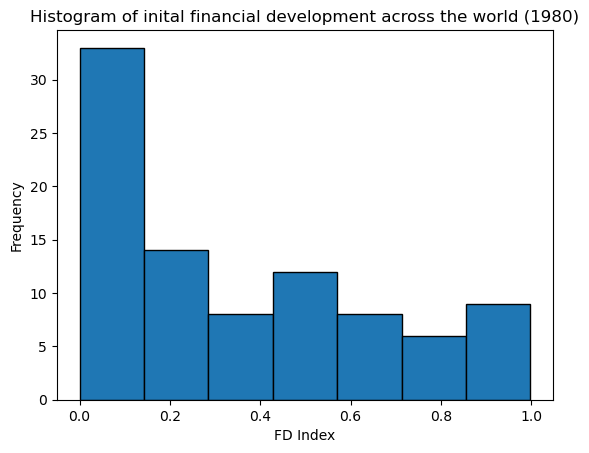

In [136]:
initial_ratios = filtered_df.groupby('country')['FMD'].first().reset_index()
plt.hist(initial_ratios['FMD'], bins=7, edgecolor='black')
plt.title('Histogram of inital financial development across the world (1980)')
plt.xlabel('FD Index')
plt.ylabel('Frequency')
plt.show()

In [137]:
# Define categories based on the initial ratio
bins = np.linspace(0, 1, num=4)
labels = ['Lav FD lande', 'Mellem FD lande', 'Høj FD lande']

# Create a new column for the categories
initial_ratios['FD_Category'] = pd.cut(initial_ratios['FMD'], bins=bins, labels=labels, right=False)

# Merge the categories back into the main DataFrame
categorized_df = pd.merge(filtered_df, initial_ratios[['country', 'FD_Category']], on='country', how='left')
categorized_df

,country,year,FD,FID,FMD,countrycode,y,k,emp,hc,...,cap_out,HC,capsh,lnY,ln_capsh,ln_labsh,ln_cap_out,ln_cap_out_neg,country_category,FD_Category
0,Angola,2019,0.096969,0.045453,0.100247,AGO,222151.062500,1.300951e+06,16.644962,1.481984,...,5.856155,24.667574,0.668858,12.311113,-0.402184,-1.105207,1.767493,-1.767493,IMF Emerging,Lav FD lande
1,Angola,2018,0.144027,0.043575,0.066922,AGO,225540.046875,1.292108e+06,16.078331,1.474635,...,5.728951,23.709661,0.668858,12.326253,-0.402184,-1.105207,1.745532,-1.745532,IMF Emerging,Lav FD lande
2,Angola,2017,0.148656,0.049994,0.067229,AGO,230151.343750,1.281953e+06,15.544552,1.467321,...,5.570045,22.808849,0.653629,12.346493,-0.425215,-1.060246,1.717403,-1.717403,IMF Emerging,Lav FD lande
3,Angola,2016,0.154190,0.056435,0.094943,AGO,230491.171875,1.267231e+06,15.028339,1.460044,...,5.497960,21.942038,0.656975,12.347968,-0.420109,-1.069952,1.704377,-1.704377,IMF Emerging,Lav FD lande
4,Angola,2015,0.147570,0.070821,0.075656,AGO,236594.859375,1.233630e+06,14.529098,1.452803,...,5.214103,21.107916,0.650872,12.374104,-0.429442,-1.052318,1.651367,-1.651367,IMF Emerging,Lav FD lande
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,Zambia,1984,0.149192,0.040375,0.040194,ZMB,14902.924805,1.874219e+05,1.943763,1.687450,...,12.576181,3.280004,0.554279,9.609313,-0.590087,-0.808062,2.531805,-2.531805,IMF Emerging,Lav FD lande
3596,Zambia,1983,0.156670,0.045299,0.045096,ZMB,14990.561523,1.915574e+05,1.893051,1.656680,...,12.778531,3.136179,0.554279,9.615176,-0.590087,-0.808062,2.547766,-2.547766,IMF Emerging,Lav FD lande
3597,Zambia,1982,0.193317,0.064173,0.063886,ZMB,14561.939453,1.953781e+05,1.861201,1.626470,...,13.417039,3.027187,0.554279,9.586166,-0.590087,-0.808062,2.596525,-2.596525,IMF Emerging,Lav FD lande
3598,Zambia,1981,0.196940,0.067229,0.066928,ZMB,14209.801758,1.983052e+05,1.814478,1.596811,...,13.955520,2.897379,0.554279,9.561687,-0.590087,-0.808062,2.635875,-2.635875,IMF Emerging,Lav FD lande


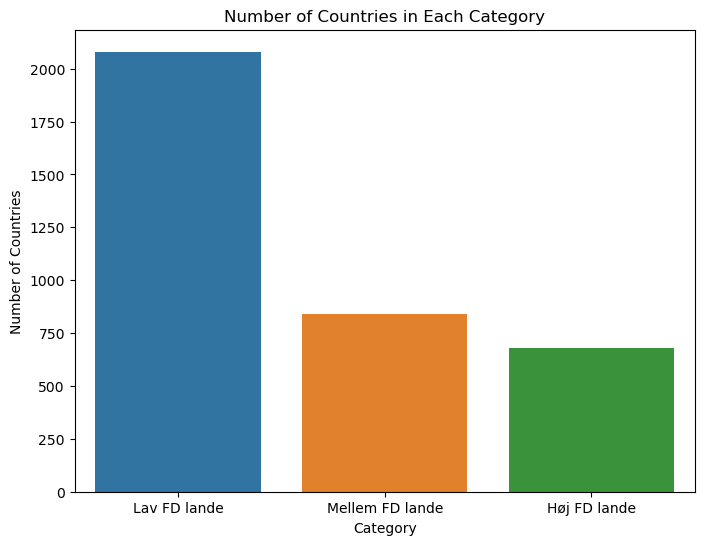

In [138]:
# Assuming 'FD_Category' is the column containing the categories
category_counts = categorized_df['FD_Category'].value_counts()

# Plotting the number of countries in each category
plt.figure(figsize=(8, 6))
sns.barplot(x=category_counts.index, y=category_counts.values)
plt.title('Number of Countries in Each Category')
plt.xlabel('Category')
plt.ylabel('Number of Countries')
plt.show()

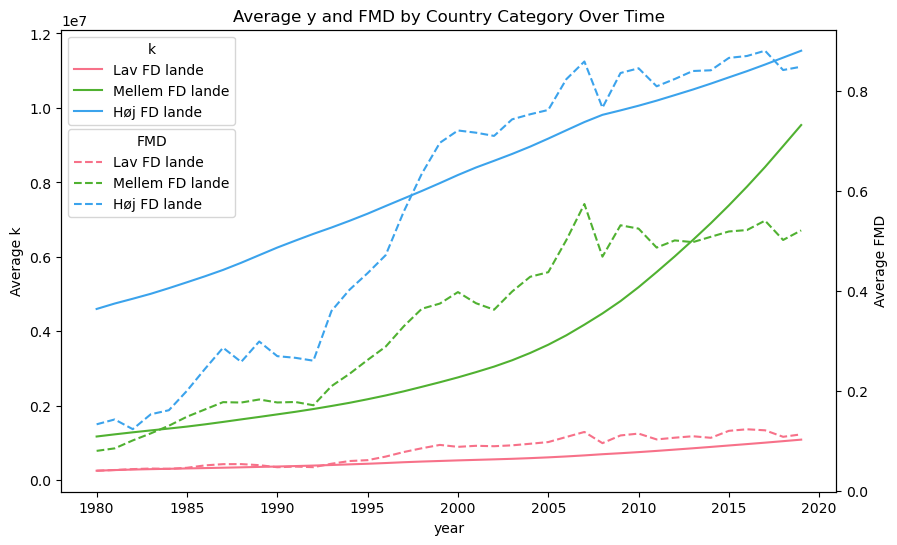

In [139]:
# Define custom color palette
custom_palette = sns.color_palette("husl", n_colors=len(avg_y.columns))

# Calculate the mean ratio for each year
avg_y = categorized_df.groupby(['year', 'FD_Category'])['k'].mean().unstack()
avg_FID = categorized_df.groupby(['year', 'FD_Category'])['FMD'].mean().unstack()

# Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot avg_y on primary axis
avg_y.plot(ax=ax1, color=custom_palette)
ax1.set_ylabel('Average k')

# Creating secondary axis
ax2 = ax1.twinx()

# Plot avg_FID on secondary axis
avg_FID.plot(ax=ax2, linestyle='--', color=custom_palette)
ax2.set_ylabel('Average FMD')

# Adding labels and title
plt.title('Average y and FMD by Country Category Over Time')
plt.xlabel('Year')

# Adding legend
legend1 = ax1.legend(title='k', loc='upper left', bbox_to_anchor=(0, 1))
legend2 = ax2.legend(title='FMD', loc='upper left', bbox_to_anchor=(0, 0.8))


# Show plot
plt.show()



In [152]:
""" 
Alternative categorization using KNearestneighbors.
"""
categorized_df['code']= pd.factorize(categorized_df['country'])[0]+1


dfA = categorized_df[['code','FD','FID','FMD','hc','lnY','ln_capsh']]

initial_ratio_df = dfA.groupby('code').first().reset_index()

In [153]:
initial_ratio_df

,code,FD,FID,FMD,hc,lnY,ln_capsh
0,1,0.096969,0.045453,0.100247,1.481984,12.311113,-0.402184
1,2,0.275159,0.161213,0.078412,3.096804,13.790776,-0.785082
2,3,0.890433,0.875603,0.933939,3.549666,14.089906,-0.847803
3,4,0.611942,0.592165,0.473552,3.381046,13.074692,-0.876732
4,5,0.159766,0.070842,0.237012,1.416526,9.132452,-0.931958
...,...,...,...,...,...,...,...
85,86,0.499584,0.068733,0.359829,2.514292,14.623257,-0.574176
86,87,0.305361,0.255330,0.060068,2.776406,11.186585,-0.642401
87,88,0.920236,0.803550,0.988402,3.749341,16.839033,-0.909045
88,89,0.592519,0.643996,0.724554,2.908202,13.504699,-0.846038


In [154]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(initial_ratio_df)

# statistics of scaled data
pd.DataFrame(data_scaled).describe()

,0,1,2,3,4,5,6
count,9.000000e+01,9.000000e+01,9.000000e+01,9.000000e+01,9.000000e+01,9.000000e+01,9.000000e+01
mean,1.480297e-17,-5.057683e-17,1.233581e-17,-6.167906e-18,1.884295e-16,-4.564250e-17,1.147230e-16
std,1.005602e+00,1.005602e+00,1.005602e+00,1.005602e+00,1.005602e+00,1.005602e+00,1.005602e+00
min,-1.712912e+00,-1.567098e+00,-1.208780e+00,-1.121694e+00,-2.198240e+00,-2.147210e+00,-3.518511e+00
25%,-8.564558e-01,-9.250912e-01,-8.361270e-01,-9.151541e-01,-6.795676e-01,-8.750055e-01,-5.394981e-01
50%,0.000000e+00,-1.261145e-01,-4.229279e-01,-3.334379e-01,1.087506e-01,5.367174e-02,-2.246098e-02
75%,8.564558e-01,8.861540e-01,9.125345e-01,7.411106e-01,6.833190e-01,7.019743e-01,6.390706e-01
max,1.712912e+00,2.059736e+00,2.071285e+00,2.097018e+00,2.319758e+00,2.393955e+00,2.222287e+00


In [157]:
# defining the kmeans function with initialization as k-means++
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=100)

# fitting the k means algorithm on scaled data
kmeans.fit(data_scaled)
pred = kmeans.predict(data_scaled)
# inertia on the fitted data
kmeans.inertia_
unique, counts = np.unique(pred, return_counts=True)

d:\Python\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [158]:
unique, counts

(array([0, 1, 2]), array([28, 39, 23], dtype=int64))

In [159]:
initial_ratio_df['Kmeans_label'] = kmeans.labels_

In [181]:
initial_ratio_df

,code,FD,FID,FMD,hc,lnY,ln_capsh,Kmeans_label
0,1,0.096969,0.045453,0.100247,1.481984,12.311113,-0.402184,2
1,2,0.275159,0.161213,0.078412,3.096804,13.790776,-0.785082,1
2,3,0.890433,0.875603,0.933939,3.549666,14.089906,-0.847803,0
3,4,0.611942,0.592165,0.473552,3.381046,13.074692,-0.876732,0
4,5,0.159766,0.070842,0.237012,1.416526,9.132452,-0.931958,2
...,...,...,...,...,...,...,...,...
85,86,0.499584,0.068733,0.359829,2.514292,14.623257,-0.574176,1
86,87,0.305361,0.255330,0.060068,2.776406,11.186585,-0.642401,1
87,88,0.920236,0.803550,0.988402,3.749341,16.839033,-0.909045,0
88,89,0.592519,0.643996,0.724554,2.908202,13.504699,-0.846038,0


In [161]:
categorized_df

,country,year,FD,FID,FMD,countrycode,y,k,emp,hc,...,HC,capsh,lnY,ln_capsh,ln_labsh,ln_cap_out,ln_cap_out_neg,country_category,FD_Category,code
0,Angola,2019,0.096969,0.045453,0.100247,AGO,222151.062500,1.300951e+06,16.644962,1.481984,...,24.667574,0.668858,12.311113,-0.402184,-1.105207,1.767493,-1.767493,IMF Emerging,Lav FD lande,1
1,Angola,2018,0.144027,0.043575,0.066922,AGO,225540.046875,1.292108e+06,16.078331,1.474635,...,23.709661,0.668858,12.326253,-0.402184,-1.105207,1.745532,-1.745532,IMF Emerging,Lav FD lande,1
2,Angola,2017,0.148656,0.049994,0.067229,AGO,230151.343750,1.281953e+06,15.544552,1.467321,...,22.808849,0.653629,12.346493,-0.425215,-1.060246,1.717403,-1.717403,IMF Emerging,Lav FD lande,1
3,Angola,2016,0.154190,0.056435,0.094943,AGO,230491.171875,1.267231e+06,15.028339,1.460044,...,21.942038,0.656975,12.347968,-0.420109,-1.069952,1.704377,-1.704377,IMF Emerging,Lav FD lande,1
4,Angola,2015,0.147570,0.070821,0.075656,AGO,236594.859375,1.233630e+06,14.529098,1.452803,...,21.107916,0.650872,12.374104,-0.429442,-1.052318,1.651367,-1.651367,IMF Emerging,Lav FD lande,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,Zambia,1984,0.149192,0.040375,0.040194,ZMB,14902.924805,1.874219e+05,1.943763,1.687450,...,3.280004,0.554279,9.609313,-0.590087,-0.808062,2.531805,-2.531805,IMF Emerging,Lav FD lande,90
3596,Zambia,1983,0.156670,0.045299,0.045096,ZMB,14990.561523,1.915574e+05,1.893051,1.656680,...,3.136179,0.554279,9.615176,-0.590087,-0.808062,2.547766,-2.547766,IMF Emerging,Lav FD lande,90
3597,Zambia,1982,0.193317,0.064173,0.063886,ZMB,14561.939453,1.953781e+05,1.861201,1.626470,...,3.027187,0.554279,9.586166,-0.590087,-0.808062,2.596525,-2.596525,IMF Emerging,Lav FD lande,90
3598,Zambia,1981,0.196940,0.067229,0.066928,ZMB,14209.801758,1.983052e+05,1.814478,1.596811,...,2.897379,0.554279,9.561687,-0.590087,-0.808062,2.635875,-2.635875,IMF Emerging,Lav FD lande,90


In [162]:
categorized_df_final = pd.merge(categorized_df,initial_ratio_df[['code','Kmeans_label']], how='left', on='code')
categorized_df_final

,country,year,FD,FID,FMD,countrycode,y,k,emp,hc,...,capsh,lnY,ln_capsh,ln_labsh,ln_cap_out,ln_cap_out_neg,country_category,FD_Category,code,Kmeans_label
0,Angola,2019,0.096969,0.045453,0.100247,AGO,222151.062500,1.300951e+06,16.644962,1.481984,...,0.668858,12.311113,-0.402184,-1.105207,1.767493,-1.767493,IMF Emerging,Lav FD lande,1,2
1,Angola,2018,0.144027,0.043575,0.066922,AGO,225540.046875,1.292108e+06,16.078331,1.474635,...,0.668858,12.326253,-0.402184,-1.105207,1.745532,-1.745532,IMF Emerging,Lav FD lande,1,2
2,Angola,2017,0.148656,0.049994,0.067229,AGO,230151.343750,1.281953e+06,15.544552,1.467321,...,0.653629,12.346493,-0.425215,-1.060246,1.717403,-1.717403,IMF Emerging,Lav FD lande,1,2
3,Angola,2016,0.154190,0.056435,0.094943,AGO,230491.171875,1.267231e+06,15.028339,1.460044,...,0.656975,12.347968,-0.420109,-1.069952,1.704377,-1.704377,IMF Emerging,Lav FD lande,1,2
4,Angola,2015,0.147570,0.070821,0.075656,AGO,236594.859375,1.233630e+06,14.529098,1.452803,...,0.650872,12.374104,-0.429442,-1.052318,1.651367,-1.651367,IMF Emerging,Lav FD lande,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,Zambia,1984,0.149192,0.040375,0.040194,ZMB,14902.924805,1.874219e+05,1.943763,1.687450,...,0.554279,9.609313,-0.590087,-0.808062,2.531805,-2.531805,IMF Emerging,Lav FD lande,90,1
3596,Zambia,1983,0.156670,0.045299,0.045096,ZMB,14990.561523,1.915574e+05,1.893051,1.656680,...,0.554279,9.615176,-0.590087,-0.808062,2.547766,-2.547766,IMF Emerging,Lav FD lande,90,1
3597,Zambia,1982,0.193317,0.064173,0.063886,ZMB,14561.939453,1.953781e+05,1.861201,1.626470,...,0.554279,9.586166,-0.590087,-0.808062,2.596525,-2.596525,IMF Emerging,Lav FD lande,90,1
3598,Zambia,1981,0.196940,0.067229,0.066928,ZMB,14209.801758,1.983052e+05,1.814478,1.596811,...,0.554279,9.561687,-0.590087,-0.808062,2.635875,-2.635875,IMF Emerging,Lav FD lande,90,1


In [241]:
klabels = categorized_df_final['Kmeans_label'].unique()
country_bins = []
year_slice = categorized_df_final[categorized_df_final['year']==2000]

for label in klabels:
    temp = year_slice[year_slice['Kmeans_label']==label]
    temp = temp['country'].reset_index()
    temp = temp.rename(columns={'country':f'Group: {label}'})
    country_bins.append(temp)

category_df = pd.concat(country_bins, axis=1)
category_df = category_df[['Group: 0','Group: 1','Group: 2',]]

In [242]:
category_df

,Group: 0,Group: 1,Group: 2
0,Australia,Argentina,Angola
1,Austria,Bulgaria,Burundi
2,Belgium,Bahrain,Benin
3,Brazil,Botswana,Burkina Faso
4,Canada,Colombia,Barbados
5,Switzerland,Costa Rica,Central African Republic
6,Chile,Cyprus,Cameroon
7,China,Dominican Republic,Ecuador
8,Germany,Gabon,Fiji
9,Denmark,Greece,Guatemala


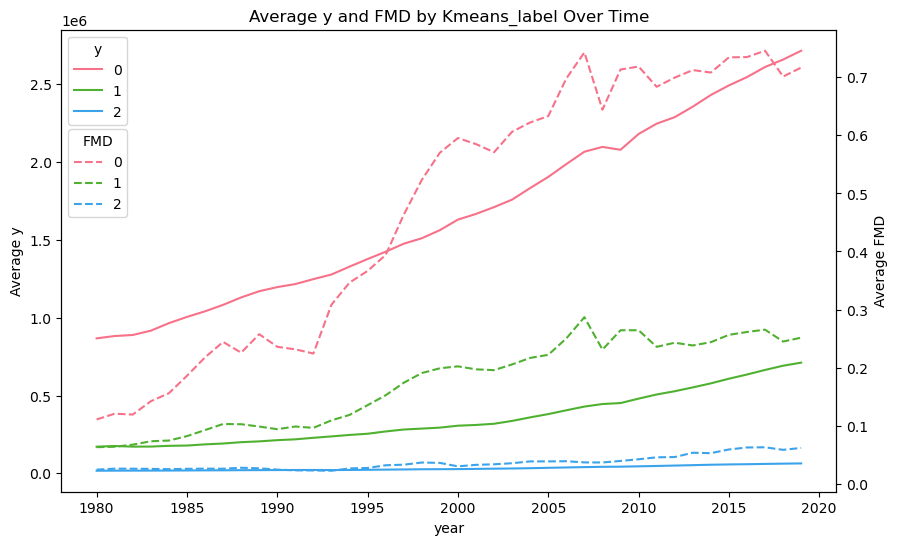

In [245]:
# Calculate the mean ratio for each year
avg_y2 = categorized_df_final.groupby(['year', 'Kmeans_label'])['y'].mean().unstack()
avg_k2 = categorized_df_final.groupby(['year', 'Kmeans_label'])['FMD'].mean().unstack()

# Define custom color palette
custom_palette = sns.color_palette("husl", n_colors=len(avg_y2.columns))
# Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot avg_y on primary axis
avg_y2.plot(ax=ax1, color=custom_palette)
ax1.set_ylabel('Average y')

# Creating secondary axis
ax2 = ax1.twinx()

# Plot avg_FID on secondary axis
avg_k2.plot(ax=ax2, linestyle='--', color=custom_palette)
ax2.set_ylabel('Average FMD')

# Adding labels and title
plt.title('Average y and FMD by Kmeans_label Over Time')
plt.xlabel('Year')

# Adding legend
legend1 = ax1.legend(title='y', loc='upper left', bbox_to_anchor=(0, 1))
legend2 = ax2.legend(title='FMD', loc='upper left', bbox_to_anchor=(0, 0.8))


# Show plot
plt.show()

